# Simulation of Heat Diffusion and Computational Efficiency

With Python, it is possible to simulate partial differential equation behavior with numerical methods and linear algebra to compute. In this post, the focus will be to simulate the 2D diffusion equation, written as:

\begin{equation}
\frac{\partial f(x,y,t)}{\partial t} = \frac{\partial^2 f}{\partial x^2} + \frac{\partial^2 f}{\partial y^2}
\end{equation}

This post will use the following discretization of the diffusion equation.

\begin{equation}
u_{i,j}^{k+1} \approx u_{i,j}^k + \epsilon \cdot \left( u_{i+1,j}^k + u_{i-1,j}^k + u_{i,j+1}^k + u_{i,j-1}^k - 4 u_{i,j}^k \right)
\end{equation}

Since there are different approaches at performing the discretization algorithm, the target is to compare the computational cost of different techniques. The Python methods used are:

- Numpy Array Python Multiplication
- Sparse Matrix Python Multiplication
- Numba Entry-Wise Computation

The below imports are all necessary packages for the computations.

In [1]:
### Package Imports ###
import numpy as np
# Output display settings, testing purposes.
np.set_printoptions(threshold=100)

# Plotting functions.
from matplotlib import pyplot as plt
# Sparse matrix computations.
from scipy.sparse import dia_array
# Accelerating code.
from numba import jit
# Timing package
import cProfile
import timeit

## Constructing Matrix

Prior to running any diffusion simulations, the initial conditions must be included and the discretization must be constructed as a Numpy array. The initial conditions will be inputted manually and the discretization will be constructed using the np.diag() function to construct a series of diagonal arrays. 

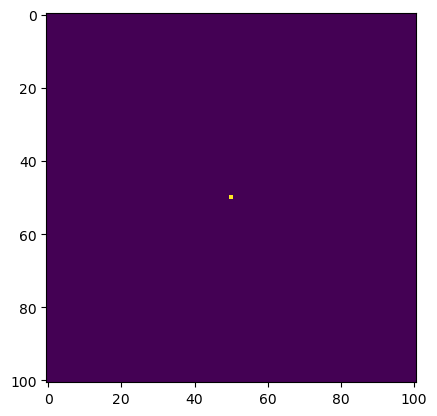

In [2]:
### Given Parameters ###
# Number of discretization steps
N = 101
epsilon = 0.2
# Initial condition: 1 unit of heat at midpoint. 
u0 = np.zeros((N, N))
u0[int(N/2), int(N/2)] = 1.0
plt.imshow(u0)

In [3]:
### Constructing Matrix A ###
# Main Diagonal #
A = np.diag([-4 for i in range(N**2)])

# 1 Left Diagonal #
A = A + np.diag([1 if (i+1)%N != 0 else 0 for i in range(N**2-1)],-1)

# 2 Left Diagonal #
A = A + np.diag([1 for i in range(N**2-N)],-N)

# 1 Right Diagonal #
A = A + np.diag([1 if (i+1)%N != 0 else 0 for i in range(N**2-1)],1)

# 2 Right Diagonal #
A = A + np.diag([1 for i in range(N**2-N)],N)

## Simulating with Numpy Matrix Multiplication

The first computation we are interested in trying is with using Numpy arrays and matrix multiplication. The functions to handle these computations will be written first, then the computation will be timed then plotted. 

In [4]:
### Plotting Function ###
def diffusion_plot(u_list,method):
    """
    The diffusion_plot() function is used for plotting the
    diffusion simulation using contourf maps.
    --
    Output: 
    - plt.figure; Matplotlib figure object to plot
    simulation.
    --
    Parameters: 
    - u_list: list; List of numpy arrays to plot.
    - method: str; Define which method used, applied to 
    title of figure.
    """
    # Setting up plot layout.
    fig, ax = plt.subplots(3,3, figsize=(8,8))
    ax = np.ravel(ax)
    
    # Iterative process of plotting each array.
    for plot in range(9):
        ax[int(plot)].contourf(u_list[plot])
        ax[int(plot)].set_title(f"{(plot+1)*300} Iterations")
    
    # Reshaping axis layout and formatting.
    ax = np.reshape(ax, (3,3))
    fig.suptitle(f"Simulating Diffusion with {method}, 2700 Iterations")
    plt.tight_layout()

    return fig

In [5]:
### Matrix Multiplication Function ###
def diffusion_pymult(A_mat,u_ic,iterations):
    """
    The diffusion_pymult() function simulates the behavior 
    of the 2D diffusion equation by using the Python matrix
    multiplication function.
    --
    Output: 
    - u: numpy.array; Solution of the system after a given
    amount of iterations.
    - u_store: list; Stored solutions to the system every
    300 iterations.
    --
    Parameters:
    - A_mat: numpy.array, size=N^2xN^2; Matrix discretization of the
    diffusion equation.
    - u_ic: numpy.array, size=N^2; Initial condition of the
    diffusion equation.
    - iterations: int; Total number of iterations to perform.
    """
    # Storing Parameters #
    u = u_ic.copy()
    u_store = []
    
    # Update Equation #
    for i in range(1,iterations+1):
        u = u + epsilon * (A_mat @ u.flatten()).reshape((N, N))
    
        # Storing entries 
        if i%300 == 0:
            u_store.append(u)
    
    return u, u_store

In [6]:
### Timing Computational Speed ###
cProfile.run("u1, u1_iter = diffusion_pymult(A,u0,2700)")

         5414 function calls in 1533.872 seconds

   Ordered by: standard name

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
        1 1533.826 1533.826 1533.872 1533.872 1958445707.py:2(diffusion_pymult)
        1    0.000    0.000 1533.872 1533.872 <string>:1(<module>)
        1    0.000    0.000 1533.872 1533.872 {built-in method builtins.exec}
        9    0.000    0.000    0.000    0.000 {method 'append' of 'list' objects}
        1    0.000    0.000    0.000    0.000 {method 'copy' of 'numpy.ndarray' objects}
        1    0.000    0.000    0.000    0.000 {method 'disable' of '_lsprof.Profiler' objects}
     2700    0.030    0.000    0.030    0.000 {method 'flatten' of 'numpy.ndarray' objects}
     2700    0.016    0.000    0.016    0.000 {method 'reshape' of 'numpy.ndarray' objects}




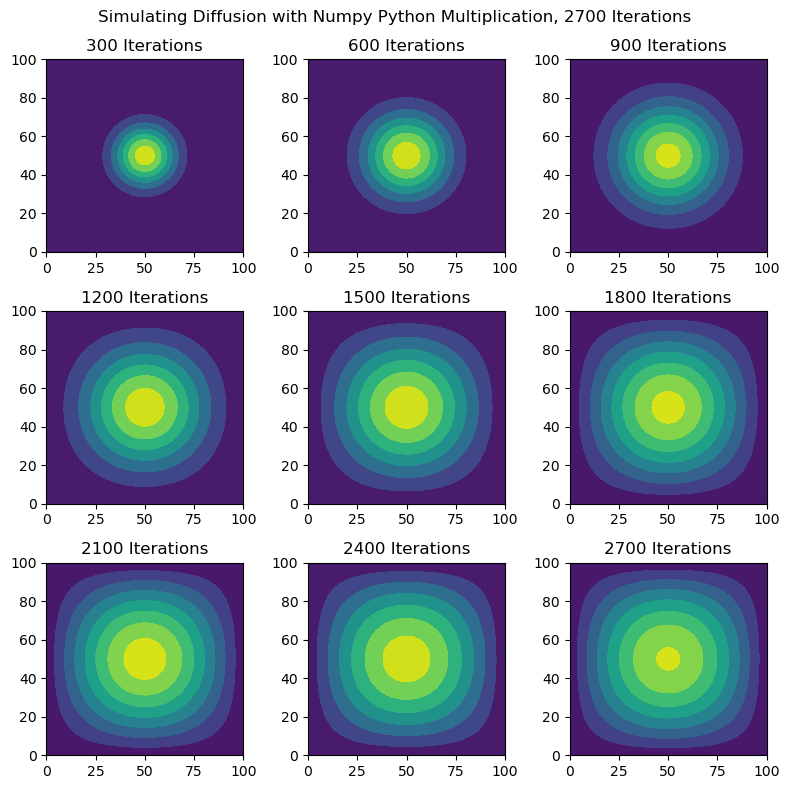

In [7]:
### Computing and Plotting with Numpy Python Multiplication ###
u1, u1_iter = diffusion_pymult(A,u0,2700)
plot1 = diffusion_plot(u1_iter,method="Numpy Python Multiplication")

## Sparse Matrix

This computation is similar to the previous section, except using a Sparse matrix from the Scipy package rather than Numpy arrays. Python's base matrix multiplication function will still be used. The functions to handle these computations are the same as the previous section. The computation will be timed then plotted as before.

In [8]:
### Redefining A as a Sparse Matrix ###
A_dia_matrix = dia_array(A)

In [9]:
### Timing Computational Speed ###
cProfile.run("u2, u2_iter = diffusion_pymult(A_dia_matrix,u0,2700)")

         64874 function calls (64862 primitive calls) in 0.232 seconds

   Ordered by: standard name

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
        1    0.042    0.042    0.232    0.232 1958445707.py:2(diffusion_pymult)
       13    0.000    0.000    0.000    0.000 <__array_function__ internals>:177(can_cast)
        1    0.000    0.000    0.000    0.000 <__array_function__ internals>:177(result_type)
        1    0.000    0.000    0.232    0.232 <string>:1(<module>)
     8100    0.001    0.000    0.001    0.000 _base.py:119(get_shape)
     2700    0.003    0.000    0.166    0.000 _base.py:510(_mul_dispatch)
     2700    0.002    0.000    0.179    0.000 _base.py:626(__matmul__)
     2700    0.001    0.000    0.001    0.000 _data.py:23(_get_dtype)
     2700    0.009    0.000    0.162    0.000 _dia.py:262(_mul_vector)
     2700    0.002    0.000    0.010    0.000 _sputils.py:211(isscalarlike)
        1    0.000    0.000    0.000    0.000 _sputils.py:22(u

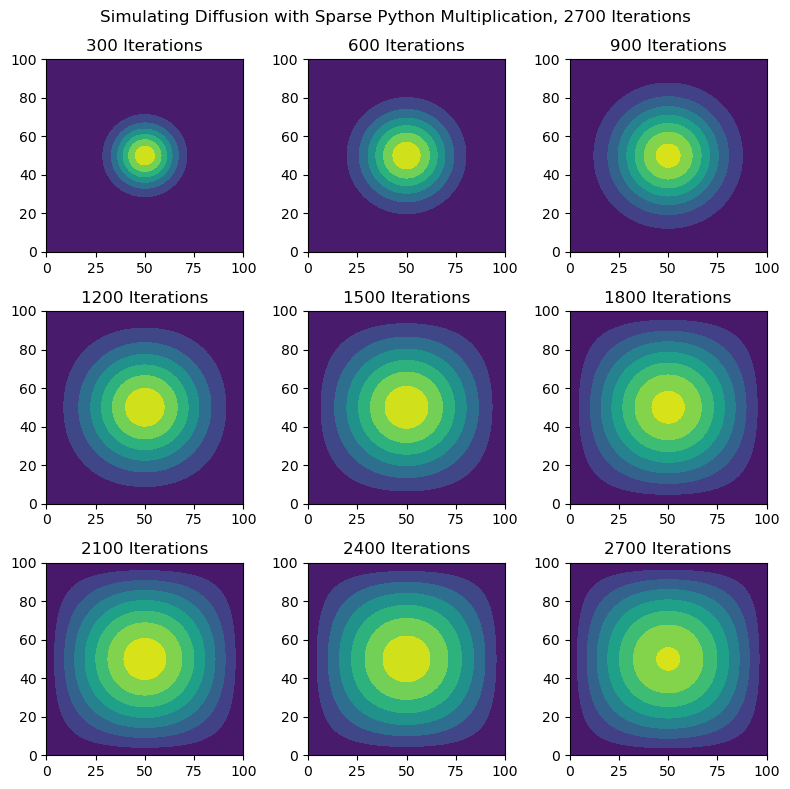

In [10]:
### Computing and Plotting with Sparse Python Multiplication ###
u2, u2_iter = diffusion_pymult(A_dia_matrix,u0,2700)
plot2 = diffusion_plot(u2_iter,method="Sparse Python Multiplication")

## Using Numba

This final approach is different, utilizing entry-wise computations in combination with Numba to accelerate computation speeds. The function to handle the computation will be written first, followed by the same timing and plotting methods as before. 

In [11]:
### Numba + For Loop Function ###
@jit(nopython=True)
def diffusion_per_entry(N_size,u_ic,iterations):
    """
    The diffusion_per_entry() function simulates the 2D 
    diffusion equation by computing each entry of the 
    matrix u manually and combining it with Numba to
    accelerate the computational speed. 
    --
    Output: 
    - u: numpy.array; Solution of the system after a given
    amount of iterations.
    - u_store: list; Stored solutions to the system every
    300 iterations.
    --
    Parameters: 
    - N_size: int; Size of diffusion matrix.
    - u_ic: np.array; Initial condition to the diffusion
    simulation. 
    - iterations: int; Number of iterations to perform
    on the simulation.
    """
    # Storing Parameters #
    u = u0.copy()
    u_update = np.zeros((N_size,N_size))
    u_store = []
    
    # Number of times to iterate.
    for step in range(iterations):
        # Iterate over each row.
        for i in range(N_size):
            # Iterate over each column.
            for j in range(N_size):
                entry_ij = -4*u[i,j]
                if i > 0:
                    entry_ij = entry_ij + u[i-1,j]
                if i < N_size-1:
                    entry_ij = entry_ij + u[i+1,j]
                if j > 0:
                    entry_ij = entry_ij + u[i,j-1]   
                if j < N_size-1:
                    entry_ij = entry_ij + u[i, j+1]
                
                u_update[i,j] = u[i,j] + epsilon*entry_ij
        
        # Update the equation.
        u = u_update.copy()
        
        # Store every 300 iteration.
        if step%300 == 0:
            u_store.append(u)
    
    return u, u_store

In [12]:
### Pre-Run Cell Before Timing Simulation ###
u_test = diffusion_per_entry(N,u0,20)

In [13]:
### Timing Computational Speed ###
cProfile.run("u3, u3_iter = diffusion_per_entry(N,u0,2700)")

         14 function calls in 0.037 seconds

   Ordered by: standard name

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
        1    0.037    0.037    0.037    0.037 1443336610.py:2(diffusion_per_entry)
        1    0.000    0.000    0.037    0.037 <string>:1(<module>)
       10    0.000    0.000    0.000    0.000 serialize.py:30(_numba_unpickle)
        1    0.000    0.000    0.037    0.037 {built-in method builtins.exec}
        1    0.000    0.000    0.000    0.000 {method 'disable' of '_lsprof.Profiler' objects}




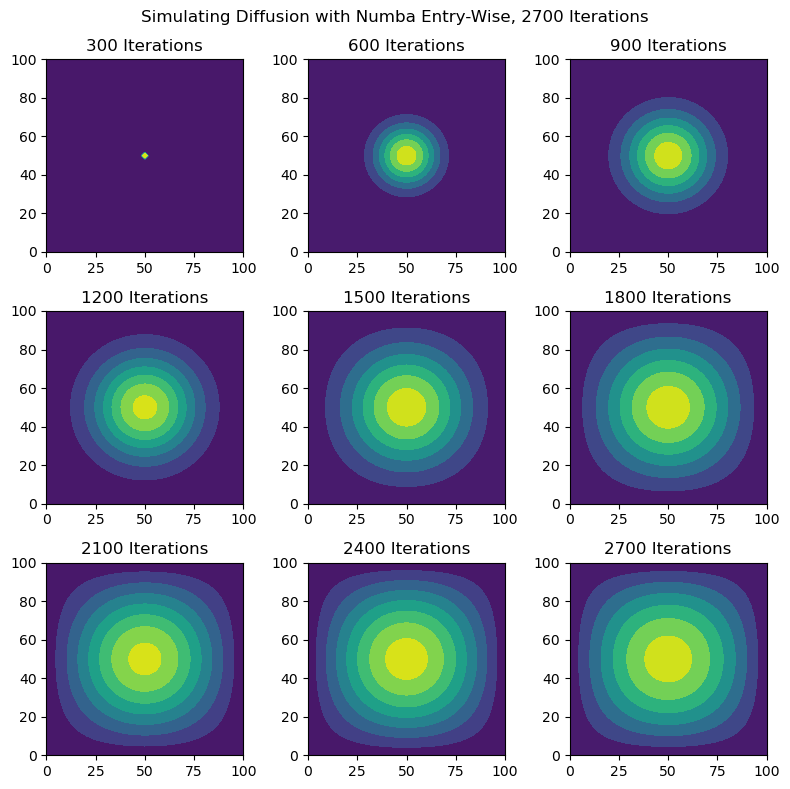

In [14]:
### Computing and Plotting with Numba Entry-Wise ###
u3, u3_iter = diffusion_per_entry(N,u0,2700)
plot3 = diffusion_plot(u3_iter,method="Numba Entry-Wise")

## Performance Comparisons

In this comparison, the performance of each method is listed below.

- Numpy Python Multiplication: 1533.872 sec -> 25.5 minutes
- Sparse Python Multiplication: 0.232 sec
- Numba Entry-Wise: 0.037 sec

In this situation, using Numpy and matrix multiplication without Numba was significantly, almost painfully slower, taking over 25 minutes to complete the simulation and plotting. From there, using a sparse matrix with Python multiplication was significantly faster. Lastly, Numba with entry-wise computations was the fastest, only taking up 0.037 seconds. By the speed of the computation, the Numba entry-wise algorithm would be the best one to use.

However, once it comes to ease of expressing the code, the Numpy or Sparse Python multiplication approach were far easier to write. The Sparse Python multiplication algorithm took a little bit extra time to accommodate for the different data type. The process for writing the code for the Numba algorithm was less intuitive for me to write. Factoring everything together, the Sparse Python multiplication algorithm was the best middle ground with both computation speed and ease of writing.